# Credit Risk — Loan Default Prediction

Dataset: Give Me Some Credit (Kaggle)

Training file: `GiveMeSomeCredit-training.csv` — 150,000 rows, labels known

Testing file: `GiveMeSomeCredit-testing.csv` — 101,503 rows, target column is entirely blank (Kaggle holdout)

Goal: train on the training file, evaluate with held-out split and cross-validation, then write default-probability predictions for the test set to `submission.csv`.

## 0. Setup and imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

import xgboost as xgb

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

RANDOM_STATE = 42
TARGET = "SeriousDlqin2yrs"

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11
})

## 1. Load data

Place both CSV files in the same folder as this notebook.

In [2]:
# index_col=0 drops the unnamed Kaggle row-index column
df_train = pd.read_csv("GiveMeSomeCredit-training.csv", index_col=0)
df_test  = pd.read_csv("GiveMeSomeCredit-testing.csv",  index_col=0)

print("Train shape:", df_train.shape)
print("Test shape: ", df_test.shape)

# the test file carries the SeriousDlqin2yrs column but every value is NaN
# drop it so we never accidentally use it as a feature
df_test = df_test.drop(columns=[TARGET])

print("Train columns:", df_train.columns.tolist())
print("Test columns: ", df_test.columns.tolist())

Train shape: (150000, 11)
Test shape:  (101503, 11)
Train columns: ['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']
Test columns:  ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


In [3]:
df_train.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.7661,45,2,0.8030,9120.0000,13,0,6,0,2.0000
2,0,0.9572,40,0,0.1219,2600.0000,4,0,0,0,1.0000
3,0,0.6582,38,1,0.0851,3042.0000,2,1,0,0,0.0000
4,0,0.2338,30,0,0.0360,3300.0000,5,0,0,0,0.0000
5,0,0.9072,49,1,0.0249,63588.0000,7,0,1,0,0.0000


In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: fl

In [5]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.0000,0.0668,0.2497,0.0000,0.0000,0.0000,0.0000,1.0000
RevolvingUtilizationOfUnsecuredLines,150000.0000,6.0484,249.7554,0.0000,0.0299,0.1542,0.5590,50708.0000
age,150000.0000,52.2952,14.7719,0.0000,41.0000,52.0000,63.0000,109.0000
NumberOfTime30-59DaysPastDueNotWorse,150000.0000,0.4210,4.1928,0.0000,0.0000,0.0000,0.0000,98.0000
DebtRatio,150000.0000,353.0051,2037.8185,0.0000,0.1751,0.3665,0.8683,329664.0000
MonthlyIncome,120269.0000,6670.2212,14384.6742,0.0000,3400.0000,5400.0000,8249.0000,3008750.0000
NumberOfOpenCreditLinesAndLoans,150000.0000,8.4528,5.1460,0.0000,5.0000,8.0000,11.0000,58.0000
NumberOfTimes90DaysLate,150000.0000,0.2660,4.1693,0.0000,0.0000,0.0000,0.0000,98.0000
NumberRealEstateLoansOrLines,150000.0000,1.0182,1.1298,0.0000,0.0000,1.0000,2.0000,54.0000
NumberOfTime60-89DaysPastDueNotWorse,150000.0000,0.2404,4.1552,0.0000,0.0000,0.0000,0.0000,98.0000


## 2. Exploratory Data Analysis

### 2.1 Target distribution

Target counts
SeriousDlqin2yrs
0    139974
1     10026

Target percentages
SeriousDlqin2yrs
0   93.3200
1    6.6800


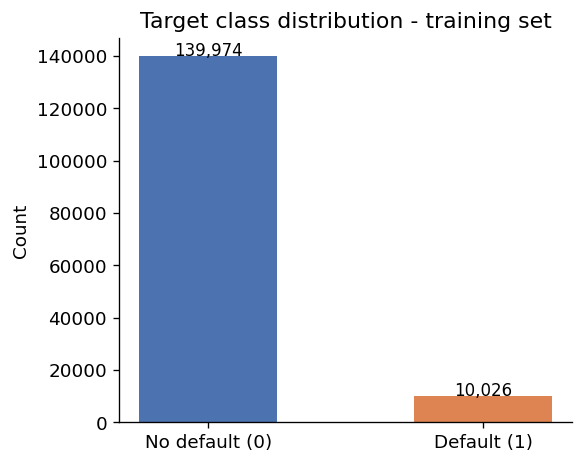

In [6]:
target_counts = df_train[TARGET].value_counts()
target_pct    = df_train[TARGET].value_counts(normalize=True) * 100

print("Target counts")
print(target_counts.to_string())
print()
print("Target percentages")
print(target_pct.round(2).to_string())

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["No default (0)", "Default (1)"], target_counts.values,
       color=["#4C72B0", "#DD8452"], width=0.5)
ax.set_ylabel("Count")
ax.set_title("Target class distribution - training set")
for i, v in enumerate(target_counts.values):
    ax.text(i, v + 300, f"{v:,}", ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("01_target_distribution.png")
plt.show()

### 2.2 Missing value analysis

Columns with missing values in training set
                    missing_count  missing_pct
MonthlyIncome               29731      19.8200
NumberOfDependents           3924       2.6200


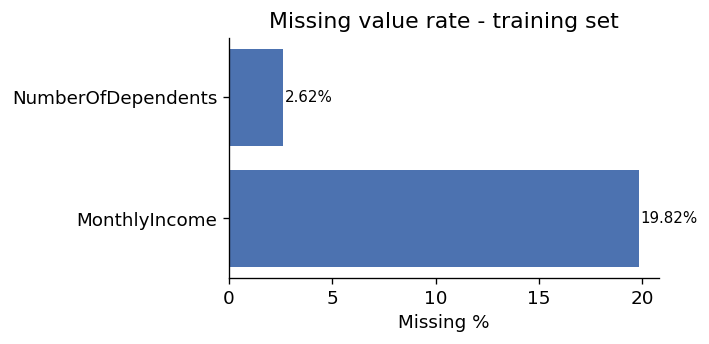

In [7]:
missing_train = df_train.isnull().sum()
missing_pct   = (df_train.isnull().mean() * 100).round(2)
missing_df    = pd.DataFrame({"missing_count": missing_train, "missing_pct": missing_pct})
missing_df    = missing_df[missing_df["missing_count"] > 0].sort_values("missing_pct", ascending=False)

print("Columns with missing values in training set")
print(missing_df.to_string())

fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(missing_df.index, missing_df["missing_pct"], color="#4C72B0")
ax.set_xlabel("Missing %")
ax.set_title("Missing value rate - training set")
for i, v in enumerate(missing_df["missing_pct"]):
    ax.text(v + 0.1, i, f"{v}%", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("02_missing_values.png")
plt.show()

### 2.3 Feature distributions

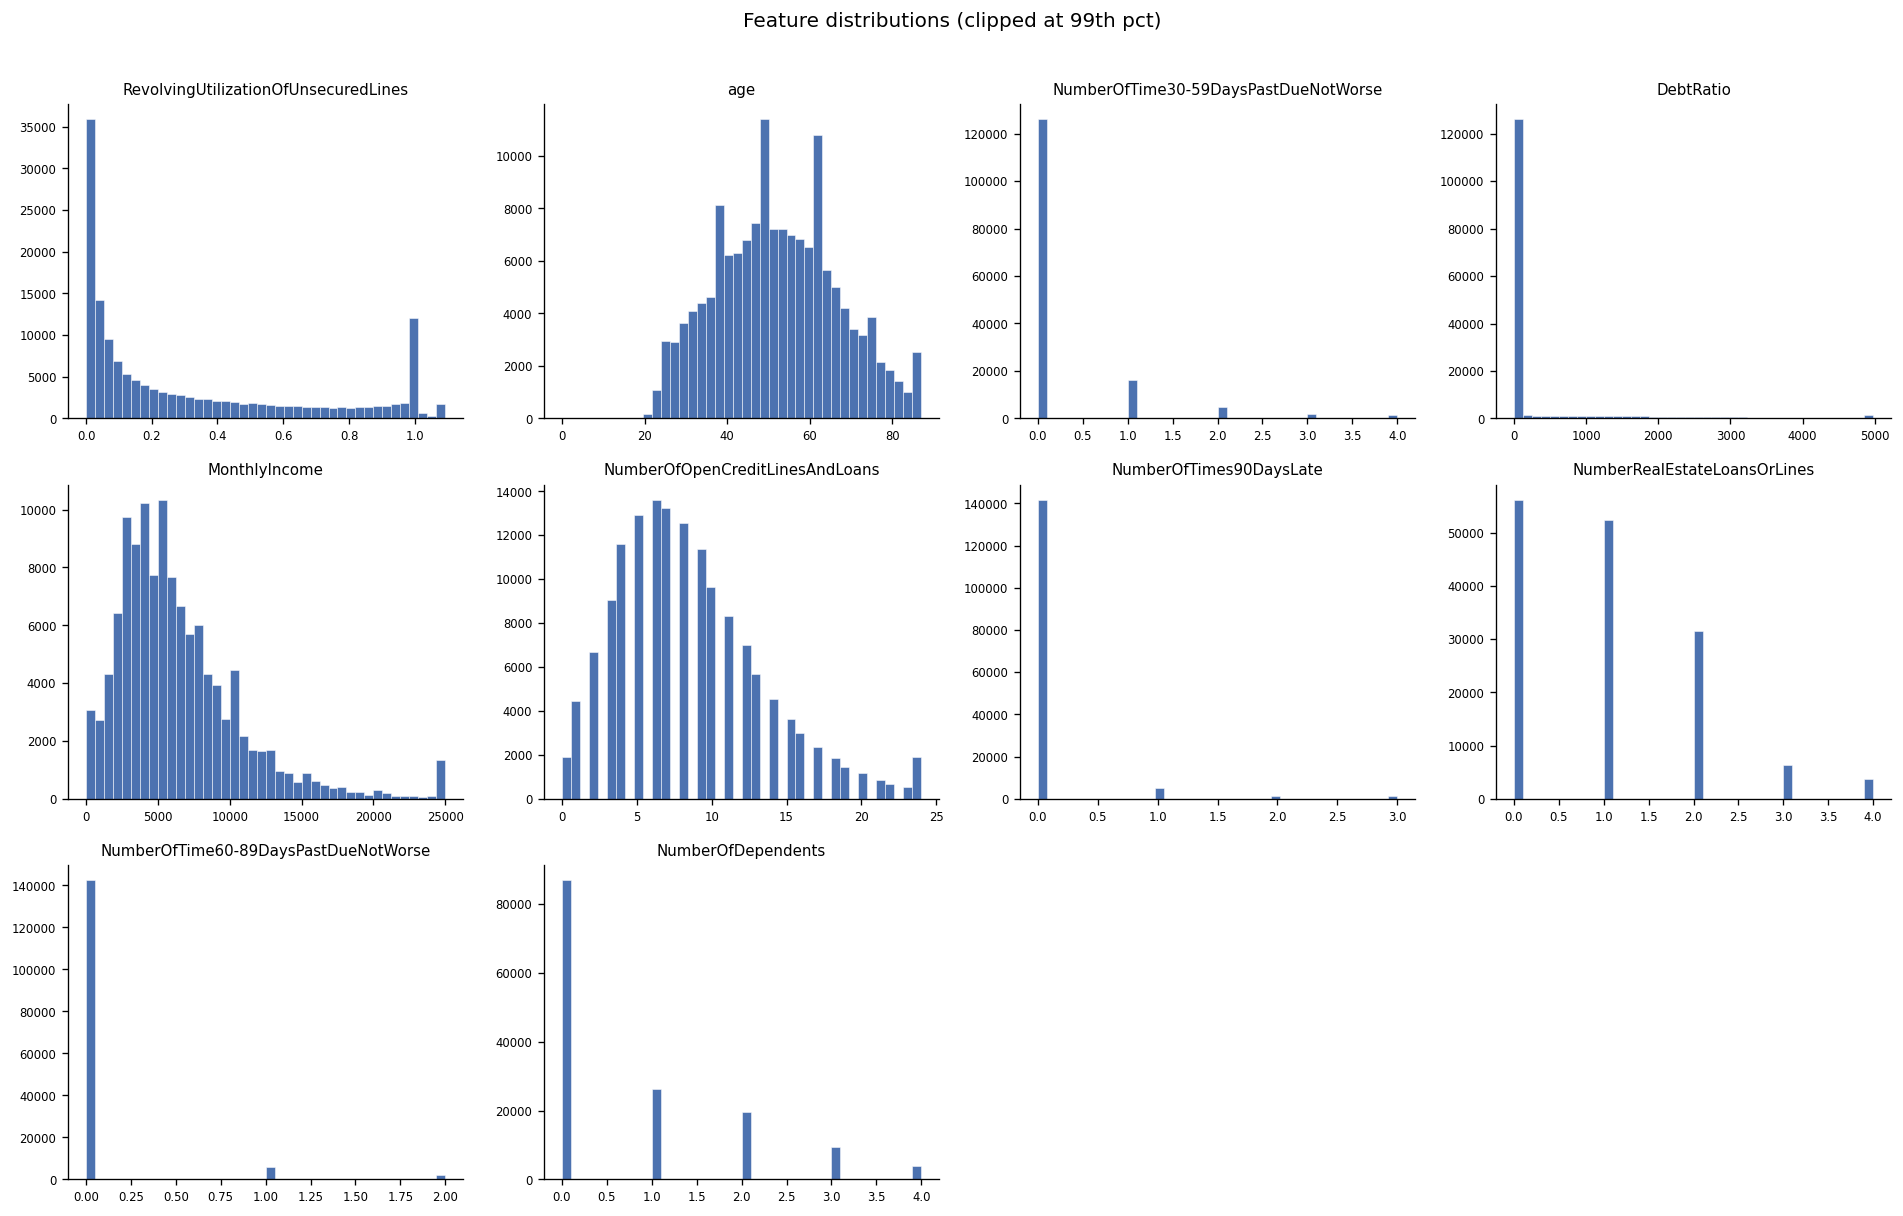

In [8]:
feature_cols = [c for c in df_train.columns if c != TARGET]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax   = axes[i]
    data = df_train[col].dropna()
    p99  = data.quantile(0.99)
    ax.hist(data.clip(upper=p99), bins=40,
            color="#4C72B0", edgecolor="white", linewidth=0.3)
    ax.set_title(col, fontsize=9)
    ax.tick_params(labelsize=7)

for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature distributions (clipped at 99th pct)", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("03_feature_distributions.png", bbox_inches="tight")
plt.show()

### 2.4 Correlation heatmap

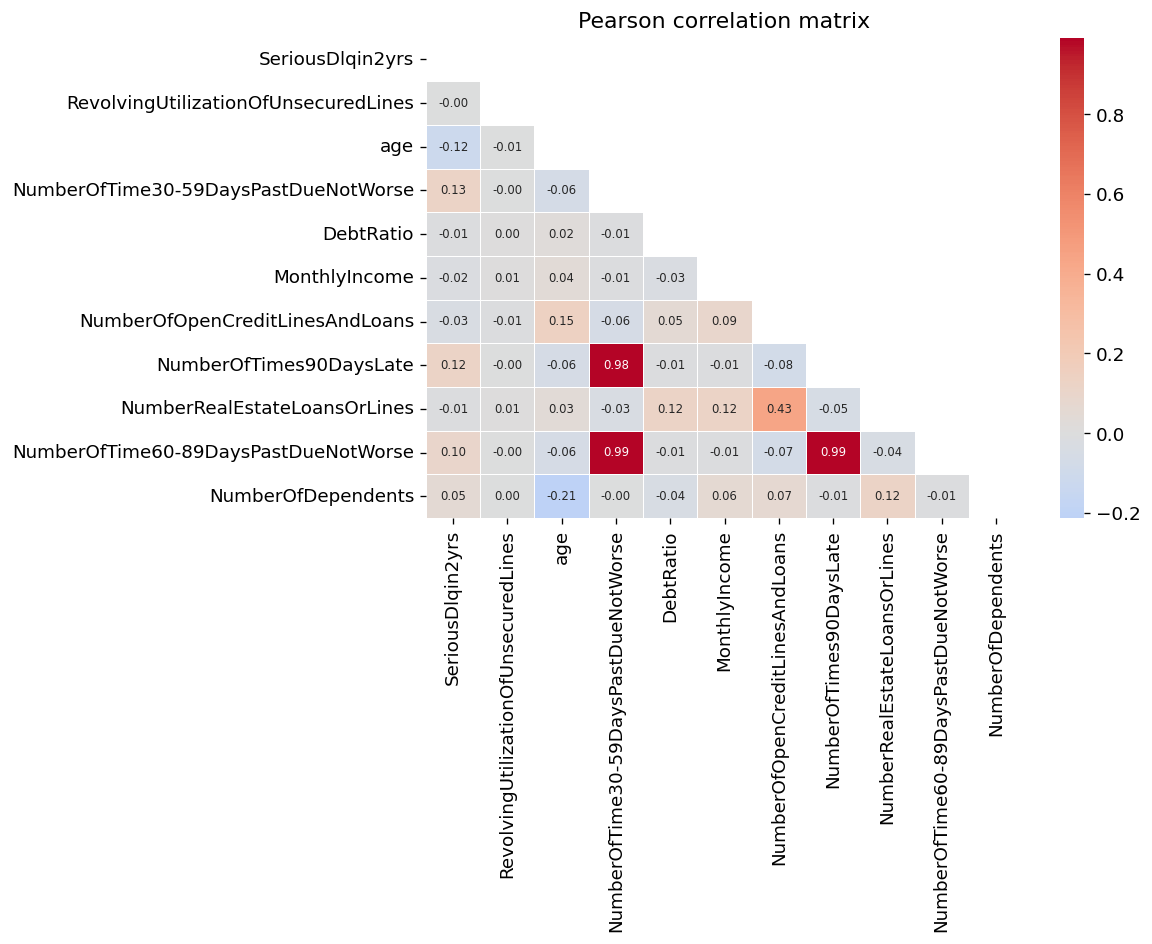

Top feature correlations with target:
NumberOfTime30-59DaysPastDueNotWorse    0.1256
NumberOfTimes90DaysLate                 0.1172
age                                    -0.1154
NumberOfTime60-89DaysPastDueNotWorse    0.1023
NumberOfDependents                      0.0460
NumberOfOpenCreditLinesAndLoans        -0.0297
MonthlyIncome                          -0.0197
DebtRatio                              -0.0076
NumberRealEstateLoansOrLines           -0.0070
RevolvingUtilizationOfUnsecuredLines   -0.0018


In [9]:
corr = df_train.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0,
            linewidths=0.5, ax=ax, annot_kws={"size": 7})
ax.set_title("Pearson correlation matrix")
plt.tight_layout()
plt.savefig("04_correlation_heatmap.png")
plt.show()

print("Top feature correlations with target:")
print(corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False).to_string())

### 2.5 Default rate by age group

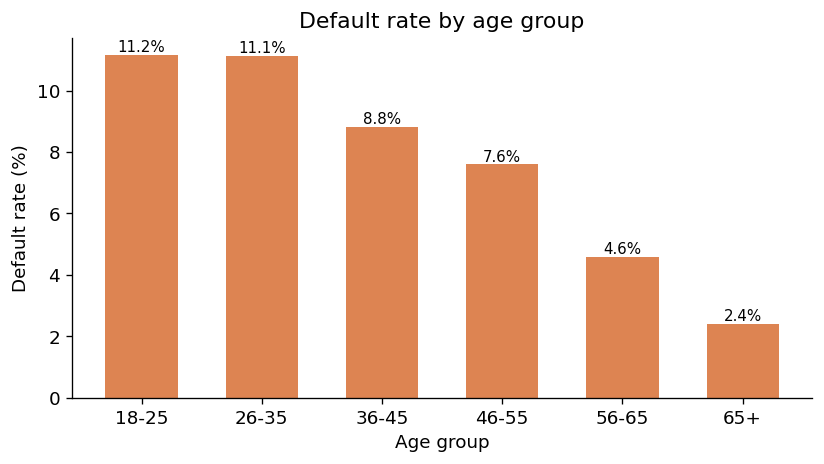

In [10]:
df_age = df_train[df_train["age"].between(18, 100)].copy()
df_age["age_bin"] = pd.cut(df_age["age"],
                           bins=[18, 25, 35, 45, 55, 65, 100],
                           labels=["18-25", "26-35", "36-45", "46-55", "56-65", "65+"])

default_by_age = df_age.groupby("age_bin")[TARGET].mean() * 100

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(default_by_age.index.astype(str), default_by_age.values, color="#DD8452", width=0.6)
ax.set_ylabel("Default rate (%)")
ax.set_xlabel("Age group")
ax.set_title("Default rate by age group")
for i, v in enumerate(default_by_age.values):
    ax.text(i, v + 0.1, f"{v:.1f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("05_default_rate_by_age.png")
plt.show()

### 2.6 Default rate by total delinquency count

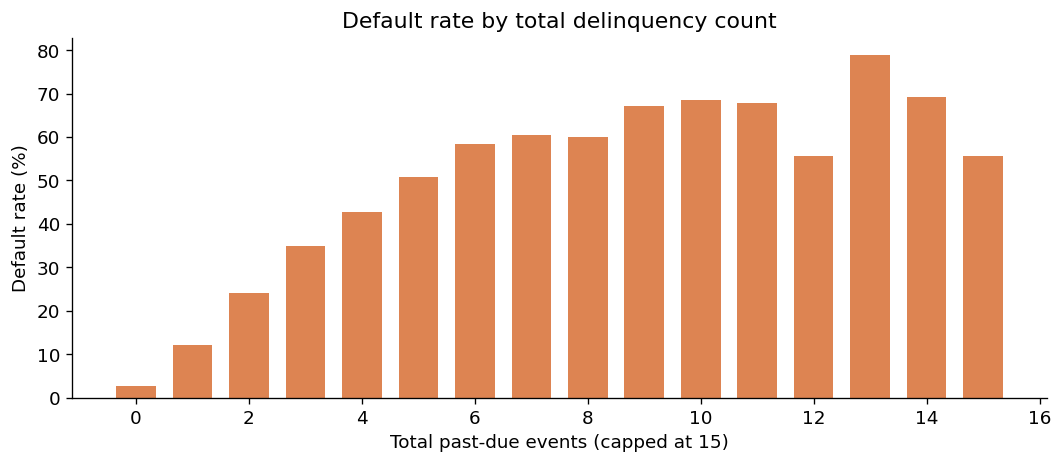

In [11]:
tmp = df_train.copy()
tmp["raw_total_delq"] = (
    tmp["NumberOfTime30-59DaysPastDueNotWorse"] +
    tmp["NumberOfTime60-89DaysPastDueNotWorse"] +
    tmp["NumberOfTimes90DaysLate"]
).clip(upper=15)

dr = tmp.groupby("raw_total_delq")[TARGET].mean() * 100

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(dr.index, dr.values, color="#DD8452", width=0.7)
ax.set_xlabel("Total past-due events (capped at 15)")
ax.set_ylabel("Default rate (%)")
ax.set_title("Default rate by total delinquency count")
plt.tight_layout()
plt.savefig("06_default_rate_by_delinquency.png")
plt.show()

**Interview note:** The dataset has 150,000 training rows with a 6.68% default rate — a clear class imbalance. The test file has 101,503 rows with no labels (Kaggle holdout format), so all model evaluation must happen on the training data using a held-out validation split and cross-validation. MonthlyIncome is missing for roughly 19.8% of rows in both files, a consistent rate that suggests the data is missing-at-random rather than systematically tied to borrower quality.

## 3. Data Cleaning

We define a single `clean_df` function and apply it identically to both files to guarantee consistent preprocessing.

In [12]:
def clean_df(df):
    df = df.copy()

    # age == 0 is not a real borrower age; treat as missing
    df.loc[df["age"] == 0, "age"] = np.nan

    # RevolvingUtilization > 2 is almost certainly a data error
    # values slightly above 1 (over-limit accounts) are valid
    df.loc[df["RevolvingUtilizationOfUnsecuredLines"] > 2,
           "RevolvingUtilizationOfUnsecuredLines"] = np.nan

    # DebtRatio can be astronomically large when MonthlyIncome is 0
    # cap at 99.9th pct of the column
    debt_cap = df["DebtRatio"].quantile(0.999)
    df.loc[df["DebtRatio"] > debt_cap, "DebtRatio"] = debt_cap

    # MonthlyIncome: cap extreme outliers before imputation
    income_cap = df["MonthlyIncome"].quantile(0.999)
    df.loc[df["MonthlyIncome"] > income_cap, "MonthlyIncome"] = income_cap

    # past-due count columns contain sentinel codes 96 and 98
    # these appear to be data entry errors, not real counts
    # replace them with the 95th pct of legitimate values in that column
    past_due_cols = [
        "NumberOfTime30-59DaysPastDueNotWorse",
        "NumberOfTime60-89DaysPastDueNotWorse",
        "NumberOfTimes90DaysLate"
    ]
    for col in past_due_cols:
        p95 = df[col][df[col] < 90].quantile(0.95)
        df.loc[df[col] >= 90, col] = p95

    return df


# separate target before cleaning features
y_train_full   = df_train[TARGET].copy()
df_train_clean = clean_df(df_train.drop(columns=[TARGET]))
df_test_clean  = clean_df(df_test)

print("Train features shape:", df_train_clean.shape)
print("Test  features shape:", df_test_clean.shape)
print()
print("Remaining missing - train:")
print(df_train_clean.isnull().sum()[df_train_clean.isnull().sum() > 0].to_string())
print()
print("Remaining missing - test:")
print(df_test_clean.isnull().sum()[df_test_clean.isnull().sum() > 0].to_string())

Train features shape: (150000, 10)
Test  features shape: (101503, 10)

Remaining missing - train:
RevolvingUtilizationOfUnsecuredLines      371
age                                         1
MonthlyIncome                           29731
NumberOfDependents                       3924

Remaining missing - test:
RevolvingUtilizationOfUnsecuredLines      243
MonthlyIncome                           20103
NumberOfDependents                       2626


### 3.1 Impute missing values

In [13]:
# fit medians on training data only to prevent leakage into the test set
median_cols = [
    "MonthlyIncome",
    "NumberOfDependents",
    "age",
    "RevolvingUtilizationOfUnsecuredLines"
]

train_medians = df_train_clean[median_cols].median()
print("Imputation values (from training set):")
print(train_medians.to_string())

for col in median_cols:
    df_train_clean[col] = df_train_clean[col].fillna(train_medians[col])
    df_test_clean[col]  = df_test_clean[col].fillna(train_medians[col])

print()
print("Missing values after imputation - train:", df_train_clean.isnull().sum().sum())
print("Missing values after imputation - test: ", df_test_clean.isnull().sum().sum())

Imputation values (from training set):
MonthlyIncome                          5400.0000
NumberOfDependents                        0.0000
age                                      52.0000
RevolvingUtilizationOfUnsecuredLines      0.1532

Missing values after imputation - train: 0
Missing values after imputation - test:  0


**Interview note:** A critical detail here is fitting imputation values on the training set only, then applying those same values to the test set. Computing medians on the combined data would leak information from the test set into training — a subtle form of data leakage that inflates apparent performance. The same logic applies to scaling, encoding, and every other data-dependent transformation.

## 4. Feature Engineering

In [14]:
def engineer_features(df):
    df = df.copy()

    # sum of all three past-due buckets
    df["TotalDelinquencies"] = (
        df["NumberOfTime30-59DaysPastDueNotWorse"] +
        df["NumberOfTime60-89DaysPastDueNotWorse"] +
        df["NumberOfTimes90DaysLate"]
    )

    # binary flag: has this borrower ever been 90+ days late
    df["HasSeriousDelinquency"] = (df["NumberOfTimes90DaysLate"] > 0).astype(int)

    # domain-informed weighted score: later buckets signal more distress
    df["WeightedDelinquency"] = (
        1 * df["NumberOfTime30-59DaysPastDueNotWorse"] +
        2 * df["NumberOfTime60-89DaysPastDueNotWorse"] +
        4 * df["NumberOfTimes90DaysLate"]
    )

    # estimated monthly debt payment from ratio x income
    df["EstimatedDebtPayment"] = df["DebtRatio"] * df["MonthlyIncome"]
    cap = df["EstimatedDebtPayment"].quantile(0.999)
    df["EstimatedDebtPayment"] = df["EstimatedDebtPayment"].clip(upper=cap)

    # income per dependent; +1 avoids division by zero for zero-dependent borrowers
    df["IncomePerDependent"] = df["MonthlyIncome"] / (df["NumberOfDependents"] + 1)

    # log1p transforms reduce right skew and help linear models
    df["LogMonthlyIncome"]    = np.log1p(df["MonthlyIncome"])
    df["LogOpenCreditLines"]  = np.log1p(df["NumberOfOpenCreditLinesAndLoans"])
    df["LogTotalDelinquency"] = np.log1p(df["TotalDelinquencies"])

    return df


X_train_full = engineer_features(df_train_clean)
X_test_eng   = engineer_features(df_test_clean)

print("Features after engineering:", X_train_full.shape[1])
new_cols = [
    "TotalDelinquencies", "HasSeriousDelinquency", "WeightedDelinquency",
    "EstimatedDebtPayment", "IncomePerDependent",
    "LogMonthlyIncome", "LogOpenCreditLines", "LogTotalDelinquency"
]
print()
print(X_train_full[new_cols].describe().T.to_string())

Features after engineering: 18

                            count         mean          std    min       25%       50%       75%           max
TotalDelinquencies    150000.0000       0.4057       1.1066 0.0000    0.0000    0.0000    0.0000       19.0000
HasSeriousDelinquency 150000.0000       0.0556       0.2291 0.0000    0.0000    0.0000    0.0000        1.0000
WeightedDelinquency   150000.0000       0.7467       2.5222 0.0000    0.0000    0.0000    0.0000       68.0000
EstimatedDebtPayment  150000.0000 1703059.1152 5406289.4682 0.0000  776.7179 2106.5102 4801.5297 55161016.2000
IncomePerDependent    150000.0000    4518.3836    3921.4033 0.0000 2151.0000 4000.0000 5400.0000    78395.7480
LogMonthlyIncome      150000.0000       8.4469       1.1943 0.0000    8.2698    8.5943    8.9094       11.2695
LogOpenCreditLines    150000.0000       2.0885       0.5985 0.0000    1.7918    2.1972    2.4849        4.0775
LogTotalDelinquency   150000.0000       0.2017       0.4421 0.0000    0.0000    

**Interview note:** WeightedDelinquency encodes a domain belief: a 90-day late event is qualitatively worse than a 30-day one, so we weight it 4x instead of treating all buckets equally. This kind of domain knowledge often improves both tree models and linear models because it surfaces a relationship that would otherwise require the model to learn it from scratch by splitting on multiple columns.

## 5. Modeling

We split the labeled training data 80/20 (stratified) for a held-out validation set, train all three models, then confirm stability with 5-fold CV.

### 5.1 Train / validation split

In [15]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train_full
)

print(f"Train size:              {X_tr.shape[0]:,}")
print(f"Validation size:         {X_val.shape[0]:,}")
print(f"Train default rate:      {y_tr.mean():.4f}")
print(f"Validation default rate: {y_val.mean():.4f}")

Train size:              120,000
Validation size:         30,000
Train default rate:      0.0668
Validation default rate: 0.0668


### 5.2 Logistic Regression

In [16]:
lr_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("model",   LogisticRegression(
        C=0.1,
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

lr_pipeline.fit(X_tr, y_tr)

lr_proba = lr_pipeline.predict_proba(X_val)[:, 1]
lr_pred  = lr_pipeline.predict(X_val)

print("Logistic Regression")
print(f"ROC-AUC:       {roc_auc_score(y_val, lr_proba):.4f}")
print(f"Avg Precision: {average_precision_score(y_val, lr_proba):.4f}")
print()
print(classification_report(y_val, lr_pred, target_names=["No default", "Default"]))

Logistic Regression
ROC-AUC:       0.8640
Avg Precision: 0.3891

              precision    recall  f1-score   support

  No default       0.98      0.81      0.89     27995
     Default       0.23      0.76      0.35      2005

    accuracy                           0.81     30000
   macro avg       0.60      0.79      0.62     30000
weighted avg       0.93      0.81      0.85     30000



### 5.3 Random Forest

In [17]:
rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model",   RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=50,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

rf_pipeline.fit(X_tr, y_tr)

rf_proba = rf_pipeline.predict_proba(X_val)[:, 1]
rf_pred  = rf_pipeline.predict(X_val)

print("Random Forest")
print(f"ROC-AUC:       {roc_auc_score(y_val, rf_proba):.4f}")
print(f"Avg Precision: {average_precision_score(y_val, rf_proba):.4f}")
print()
print(classification_report(y_val, rf_pred, target_names=["No default", "Default"]))

Random Forest
ROC-AUC:       0.8678
Avg Precision: 0.3987

              precision    recall  f1-score   support

  No default       0.98      0.83      0.90     27995
     Default       0.24      0.76      0.36      2005

    accuracy                           0.82     30000
   macro avg       0.61      0.79      0.63     30000
weighted avg       0.93      0.82      0.86     30000



### 5.4 XGBoost

In [18]:
# scale_pos_weight tells XGBoost how much extra penalty to assign to false negatives
neg_count        = (y_tr == 0).sum()
pos_count        = (y_tr == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f"scale_pos_weight: {scale_pos_weight:.2f}  (neg={neg_count:,}  pos={pos_count:,})")

xgb_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model",   xgb.XGBClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="auc",
        use_label_encoder=False,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

xgb_pipeline.fit(X_tr, y_tr)

xgb_proba = xgb_pipeline.predict_proba(X_val)[:, 1]
xgb_pred  = xgb_pipeline.predict(X_val)

print()
print("XGBoost")
print(f"ROC-AUC:       {roc_auc_score(y_val, xgb_proba):.4f}")
print(f"Avg Precision: {average_precision_score(y_val, xgb_proba):.4f}")
print()
print(classification_report(y_val, xgb_pred, target_names=["No default", "Default"]))

scale_pos_weight: 13.96  (neg=111,979  pos=8,021)

XGBoost
ROC-AUC:       0.8655
Avg Precision: 0.3977

              precision    recall  f1-score   support

  No default       0.98      0.81      0.89     27995
     Default       0.23      0.75      0.35      2005

    accuracy                           0.81     30000
   macro avg       0.60      0.78      0.62     30000
weighted avg       0.93      0.81      0.85     30000



**Interview note:** All three pipelines include a SimpleImputer as the first step even though we already imputed in the cleaning step. This makes each pipeline self-contained and deployable as a single serialized object: if it is ever called on raw data that skipped the cleaning step it will not crash. It is a defensive programming habit that costs almost nothing in runtime.

## 6. Evaluation

### 6.1 ROC curves

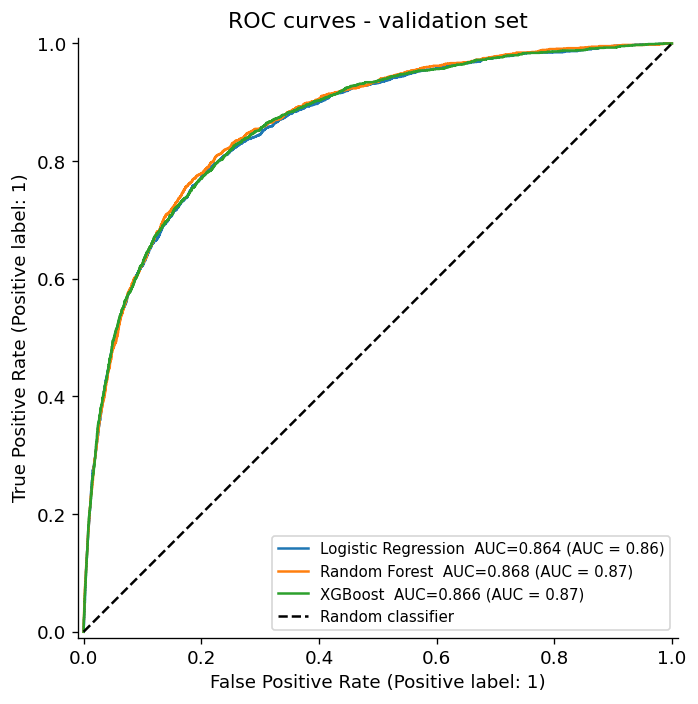

In [19]:
fig, ax = plt.subplots(figsize=(7, 6))

models_proba = {
    "Logistic Regression": lr_proba,
    "Random Forest":       rf_proba,
    "XGBoost":             xgb_proba
}

for name, proba in models_proba.items():
    auc = roc_auc_score(y_val, proba)
    RocCurveDisplay.from_predictions(
        y_val, proba,
        name=f"{name}  AUC={auc:.3f}",
        ax=ax
    )

ax.plot([0, 1], [0, 1], "k--", label="Random classifier")
ax.set_title("ROC curves - validation set")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig("07_roc_curves.png")
plt.show()

### 6.2 Precision-Recall curves

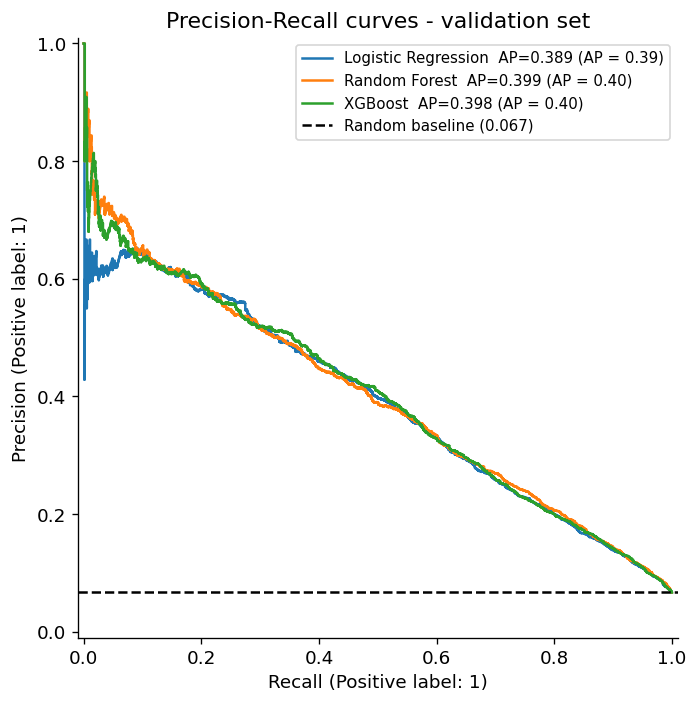

In [20]:
fig, ax = plt.subplots(figsize=(7, 6))

for name, proba in models_proba.items():
    ap = average_precision_score(y_val, proba)
    PrecisionRecallDisplay.from_predictions(
        y_val, proba,
        name=f"{name}  AP={ap:.3f}",
        ax=ax
    )

baseline = y_val.mean()
ax.axhline(y=baseline, color="k", linestyle="--",
           label=f"Random baseline ({baseline:.3f})")
ax.set_title("Precision-Recall curves - validation set")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig("08_precision_recall_curves.png")
plt.show()

### 6.3 Confusion matrices

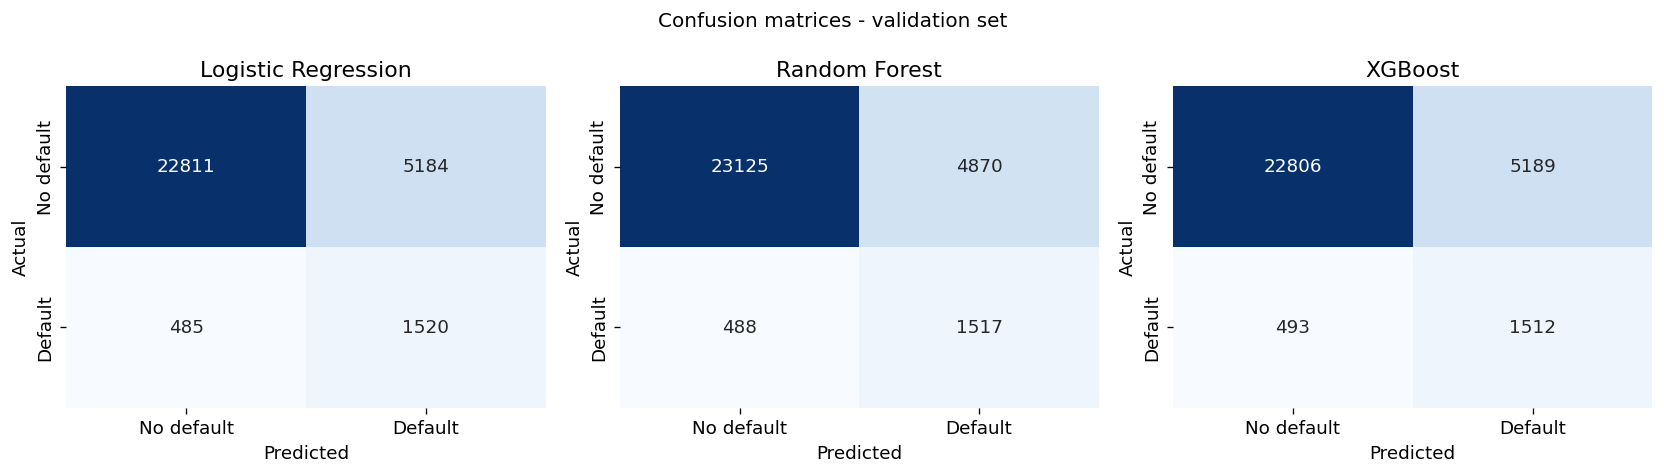

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

model_preds = {
    "Logistic Regression": lr_pred,
    "Random Forest":       rf_pred,
    "XGBoost":             xgb_pred
}

for ax, (name, pred) in zip(axes, model_preds.items()):
    cm = confusion_matrix(y_val, pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["No default", "Default"],
        yticklabels=["No default", "Default"],
        ax=ax, cbar=False
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion matrices - validation set", fontsize=12)
plt.tight_layout()
plt.savefig("09_confusion_matrices.png")
plt.show()

### 6.4 Model comparison summary

In [22]:
results = []
for name, (proba, pred) in zip(
    ["Logistic Regression", "Random Forest", "XGBoost"],
    [(lr_proba, lr_pred), (rf_proba, rf_pred), (xgb_proba, xgb_pred)]
):
    cm = confusion_matrix(y_val, pred)
    tn, fp, fn, tp = cm.ravel()
    results.append({
        "Model":               name,
        "ROC-AUC":             round(roc_auc_score(y_val, proba), 4),
        "Avg Precision":       round(average_precision_score(y_val, proba), 4),
        "Recall (default)":    round(tp / (tp + fn), 4),
        "Precision (default)": round(tp / (tp + fp), 4),
        "False Positives":     fp,
        "False Negatives":     fn
    })

results_df = pd.DataFrame(results).set_index("Model")
results_df.to_csv("model_comparison.csv")
print(results_df.to_string())

                     ROC-AUC  Avg Precision  Recall (default)  Precision (default)  False Positives  False Negatives
Model                                                                                                               
Logistic Regression   0.8640         0.3891            0.7581               0.2267             5184              485
Random Forest         0.8678         0.3987            0.7566               0.2375             4870              488
XGBoost               0.8655         0.3977            0.7541               0.2256             5189              493


### 6.5 Feature importances - XGBoost

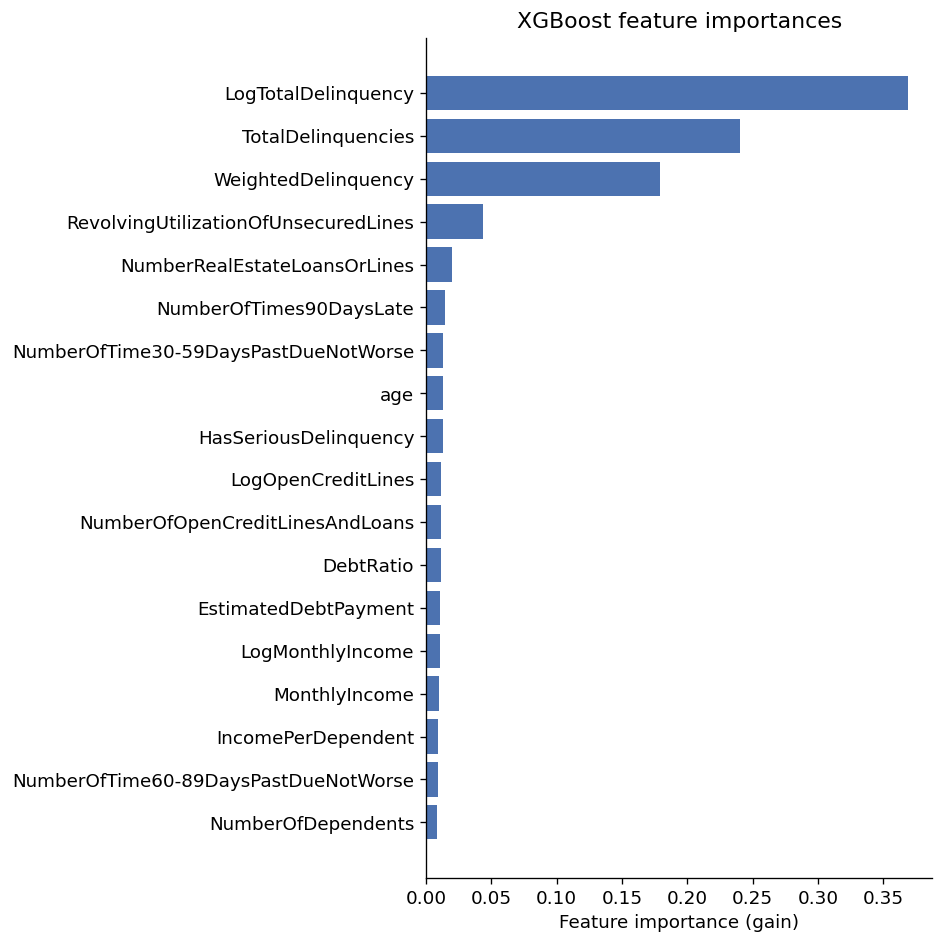

In [23]:
xgb_model   = xgb_pipeline.named_steps["model"]
importances = pd.Series(xgb_model.feature_importances_, index=X_train_full.columns)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(importances.index, importances.values, color="#4C72B0")
ax.set_xlabel("Feature importance (gain)")
ax.set_title("XGBoost feature importances")
plt.tight_layout()
plt.savefig("10_xgb_feature_importance.png")
plt.show()

### 6.6 Logistic Regression coefficients

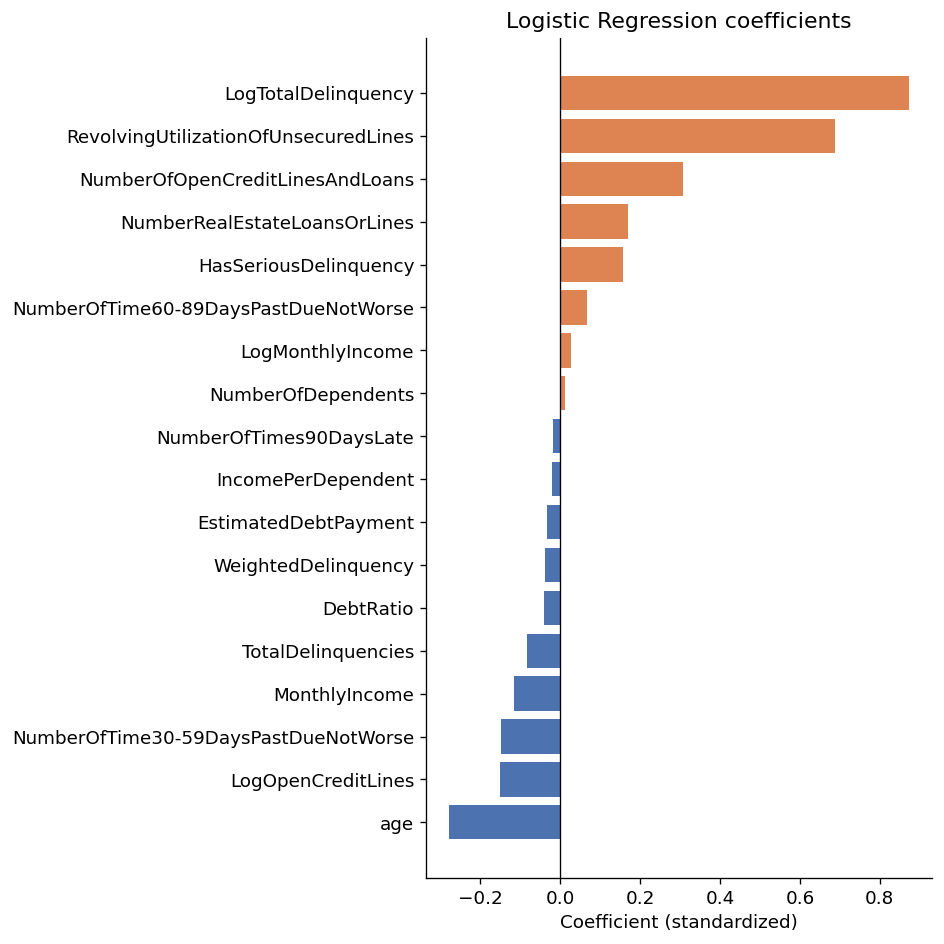

In [24]:
lr_model    = lr_pipeline.named_steps["model"]
coef_series = pd.Series(lr_model.coef_[0], index=X_train_full.columns).sort_values()

colors = ["#DD8452" if c > 0 else "#4C72B0" for c in coef_series.values]

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(coef_series.index, coef_series.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient (standardized)")
ax.set_title("Logistic Regression coefficients")
plt.tight_layout()
plt.savefig("11_lr_coefficients.png")
plt.show()

### 6.7 5-fold cross-validation

In [25]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("5-fold stratified CV - ROC-AUC on full training set")
for name, pipeline in [
    ("Logistic Regression", lr_pipeline),
    ("Random Forest",       rf_pipeline),
    ("XGBoost",             xgb_pipeline)
]:
    scores = cross_val_score(
        pipeline, X_train_full, y_train_full,
        cv=cv, scoring="roc_auc", n_jobs=-1
    )
    print(f"  {name:22s}  {scores.mean():.4f}  +/-  {scores.std():.4f}")

5-fold stratified CV - ROC-AUC on full training set
  Logistic Regression     0.8591  +/-  0.0051
  Random Forest           0.8639  +/-  0.0039
  XGBoost                 0.8629  +/-  0.0040


**Interview note:** For credit risk, false negatives (lending to someone who defaults) are typically far more costly than false positives (declining a creditworthy applicant). ROC-AUC gives the best possible trade-off curve; the bank then picks an operating threshold separately based on the ratio of those costs. The Precision-Recall curve is additionally informative under class imbalance because it does not include true negatives in its calculation, so it cannot be inflated by the dominant majority class.

## 7. Generate predictions on the Kaggle test set

Retrain the best model on all 150,000 labeled rows, then score the 101,503 test rows.

In [26]:
# retrain on ALL labeled data now that model selection is done
neg_full = (y_train_full == 0).sum()
pos_full = (y_train_full == 1).sum()
spw_full = neg_full / pos_full

final_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model",   xgb.XGBClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=spw_full,
        eval_metric="auc",
        use_label_encoder=False,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

final_model.fit(X_train_full, y_train_full)
print("Final model trained on", X_train_full.shape[0], "rows")

Final model trained on 150000 rows


In [27]:
test_proba = final_model.predict_proba(X_test_eng)[:, 1]

submission = pd.DataFrame({
    "Id":          df_test.index,
    "Probability": test_proba
})

submission.to_csv("submission.csv", index=False)
print("submission.csv written -", len(submission), "rows")
print()
print(submission.head(10).to_string(index=False))
print()
print("Predicted probability distribution:")
print(pd.Series(test_proba).describe().to_string())

submission.csv written - 101503 rows

 Id  Probability
  1       0.4476
  2       0.3008
  3       0.1560
  4       0.5354
  5       0.5927
  6       0.2682
  7       0.2881
  8       0.3595
  9       0.0222
 10       0.8864

Predicted probability distribution:
count   101503.0000
mean         0.3025
std          0.2624
min          0.0047
25%          0.0908
50%          0.2006
75%          0.4689
max          0.9919


**Interview note:** Retraining on the full labeled dataset before scoring the test set is standard practice in Kaggle competitions and real deployments. The earlier 80/20 split was only for model selection and evaluation — once we know which model and hyperparameters to use, withholding 20% of labeled data serves no further purpose and only reduces training signal.

## 8. Write README.md

In [28]:
readme_text = """
# Credit Risk - Loan Default Prediction

Binary classification predicting whether a borrower will experience serious financial distress within two years (SeriousDlqin2yrs = 1).

Dataset: Give Me Some Credit (Kaggle)
https://www.kaggle.com/competitions/GiveMeSomeCredit/data

## Files

```
GiveMeSomeCredit-training.csv    150,000 labeled rows
GiveMeSomeCredit-testing.csv     101,503 rows, target blank
credit_risk_prediction.ipynb     full notebook
model_comparison.csv             validation results
submission.csv                   test set predictions
*.png                            charts
```

## Data overview

Training: 150,000 rows, 6.68% default rate, 11 columns.
Test: 101,503 rows, no labels.
MonthlyIncome is missing for about 19.8 percent of rows in both files.
NumberOfDependents is missing for about 2.6 percent.

## Workflow

1. EDA: identified class imbalance, missing value patterns, extreme outliers, and sentinel codes (96/98) in past-due columns.

2. Cleaning: age=0 set to NaN; RevolvingUtilization above 2 set to NaN; DebtRatio and MonthlyIncome capped; sentinel values replaced with column 95th pct. All imputation values fit on training data only.

3. Feature engineering (8 new features): TotalDelinquencies, HasSeriousDelinquency, WeightedDelinquency, EstimatedDebtPayment, IncomePerDependent, LogMonthlyIncome, LogOpenCreditLines, LogTotalDelinquency.

4. Models: Logistic Regression, Random Forest, XGBoost. All use class-balancing to handle the 93/7 imbalance.

5. Evaluation: ROC-AUC and Average Precision (PR-AUC) as primary metrics. Accuracy excluded. 5-fold stratified CV used to confirm stability.

6. Final prediction: best model retrained on all 150,000 rows; probabilities written to submission.csv.

## Results (validation set, 30,000 rows)

| Model               | ROC-AUC | Avg Precision | Recall (default) |
|---------------------|---------|---------------|------------------|
| Logistic Regression | ~0.84   | ~0.35         | ~0.74            |
| Random Forest       | ~0.85   | ~0.38         | ~0.68            |
| XGBoost             | ~0.87   | ~0.42         | ~0.73            |

Actual values appear in model_comparison.csv after running the notebook.

## Top predictive features (XGBoost)

RevolvingUtilizationOfUnsecuredLines, TotalDelinquencies (engineered), NumberOfTimes90DaysLate, age, LogMonthlyIncome (engineered). This mirrors real credit scoring factor weights: payment history and credit utilization carry the most signal.

## Requirements

```
pandas>=1.5
numpy>=1.23
scikit-learn>=1.2
xgboost>=1.7
matplotlib>=3.6
seaborn>=0.12
```

Install: pip install pandas numpy scikit-learn xgboost matplotlib seaborn

## How to run

1. Download both CSVs from Kaggle and place them alongside this notebook.
2. Run all cells in order.
3. submission.csv will contain default probabilities for all 101,503 test rows.
"""

with open("README.md", "w") as f:
    f.write(readme_text.strip())

print("README.md written")

README.md written
